# 🔬 Method 2: Latent Vector Heatmap (내부 작동 원리 규명)

## 가설: "Concept은 고정되고 Residual만 흔들린다"

### 실험 방법
1. 하나의 샘플 이미지 $x$를 준비
2. 노이즈 레벨을 $\sigma = 0, 0.1, 0.3, 0.5, 1.0$으로 높여가며 임베딩 벡터를 추출
3. 벡터를 **1D 히트맵(Barcode 형태)**으로 시각화 (x축: 차원 인덱스, 색상: 값의 강도)
4. CoRes: 벡터를 `[Concept 파트 | Residual 파트]`로 시각적으로 구분

### 예상 결과
- **Baseline**: 노이즈 커질수록 바코드 **전체** 색상이 불규칙하게 변화 (전역적 붕괴)
- **CoRes**:
  - **Concept 파트**: 색상 패턴이 거의 변하지 않음 (닻 역할)
  - **Residual 파트**: 노이즈에 따라 색상이 현란하게 변화 (피뢰침 역할)

> *"Residual이 노이즈를 전부 흡수하는 동안, Concept 영역은 굳건히 정보를 보존하고 있다."*

In [1]:
import os
import sys
import yaml
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch
from PIL import Image
from torchvision import transforms

# 프로젝트 루트
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from data import get_dataloaders
from models import build_model

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()}")

/home/dojan/anaconda3/envs/cut3r/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/dojan/anaconda3/envs/cut3r/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Project root: /home/dojan/cores-embedding
CUDA available: True


## 1. 설정 로드 및 모델 준비

In [2]:
# ── 설정 로드 ──
config_path = os.path.join(PROJECT_ROOT, "configs", "default.yaml")
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
config["experiment"]["device"] = DEVICE
config["dataset"]["root"] = os.path.join(PROJECT_ROOT, "data", "raw")
config["training"]["batch_size"] = 64

# 체크포인트 경로
BASELINE_CKPT = os.path.join(
    PROJECT_ROOT, "outputs", config["experiment"]["name"],
    "baseline", "checkpoints", "best.pt"
)
CORES_CKPT = os.path.join(
    PROJECT_ROOT, "outputs", config["experiment"]["name"],
    "cores", "checkpoints", "best.pt"
)

print(f"Device: {DEVICE}")
print(f"Baseline checkpoint exists: {os.path.exists(BASELINE_CKPT)}")
print(f"CoRes checkpoint exists:    {os.path.exists(CORES_CKPT)}")

Device: cuda
Baseline checkpoint exists: True
CoRes checkpoint exists:    True


In [3]:
# ── 데이터 로더 ──
train_loader, test_loader, num_concepts = get_dataloaders(config)
print(f"Num concepts: {num_concepts}")
print(f"Test samples: {len(test_loader.dataset)}")

CONCEPT_ATTRS = config["dataset"].get("celeba_attrs", [
    "Male", "Eyeglasses", "Smiling", "Young",
    "Blond_Hair", "Black_Hair", "Brown_Hair",
    "Bangs", "Heavy_Makeup", "Wearing_Hat",
])
print(f"Concept attributes: {CONCEPT_ATTRS}")

Num concepts: 10
Test samples: 19962
Concept attributes: ['Male', 'Eyeglasses', 'Smiling', 'Young', 'Blond_Hair', 'Black_Hair', 'Brown_Hair', 'Bangs', 'Heavy_Makeup', 'Wearing_Hat']


In [4]:
# ── 모델 로드 ──
def load_model(config, model_type, checkpoint_path):
    config_copy = {k: v for k, v in config.items()}
    config_copy["_model_type"] = model_type
    if model_type == "cores":
        config_copy["model"]["cores"]["num_concepts"] = num_concepts
    model = build_model(config_copy, num_concepts)
    if os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        print(f"✅ Loaded: {checkpoint_path}")
    else:
        print(f"⚠️  Not found: {checkpoint_path}, using random weights")
    model.to(DEVICE)
    model.eval()
    return model

baseline_model = load_model(config, "baseline", BASELINE_CKPT)
cores_model = load_model(config, "cores", CORES_CKPT)

# CoRes 모델의 차원 정보 확인
concept_dim = config["model"]["cores"]["concept_dim"]
residual_dim = config["model"]["cores"]["residual_dim"]
latent_dim = config["model"]["latent_dim"]
print(f"\nCoRes dimensions: concept_dim={concept_dim}, residual_dim={residual_dim}, latent_dim={latent_dim}")

✅ Loaded: /home/dojan/cores-embedding/outputs/cores_embedding_default/baseline/checkpoints/best.pt
✅ Loaded: /home/dojan/cores-embedding/outputs/cores_embedding_default/cores/checkpoints/best.pt

CoRes dimensions: concept_dim=32, residual_dim=32, latent_dim=64


## 2. 유틸리티 함수

In [5]:
# ── 이미지/노이즈 유틸리티 ──
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(tensor):
    """ImageNet 정규화 역변환."""
    img = tensor.cpu().clone()
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return torch.clamp(img, 0, 1)


def tensor_to_numpy_img(tensor):
    """[C, H, W] 텐서 → numpy [H, W, C] uint8."""
    img = denormalize(tensor)
    img = img.permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)


def add_gaussian_noise(images, sigma):
    """가우시안 노이즈 추가."""
    noise = torch.randn_like(images) * sigma
    return torch.clamp(images + noise, -3, 3)


def concept_labels_to_str(concept_vec, attr_names, threshold=0.5):
    """개념 벡터를 문자열로 변환."""
    active = [name for val, name in zip(concept_vec, attr_names) if val > threshold]
    return ", ".join(active) if active else "(none)"


@torch.no_grad()
def extract_embeddings(model, image, sigma):
    """주어진 노이즈 수준에서 임베딩을 추출합니다.

    Returns:
        dict: Baseline -> {'z': [D]}
              CoRes   -> {'z_total': [D], 'z_concept': [concept_dim],
                          'z_residual': [residual_dim], 'concept_probs': [N]}
    """
    noisy = add_gaussian_noise(image.unsqueeze(0), sigma).to(DEVICE)

    if hasattr(model, "get_decomposed_embedding"):
        dec = model.get_decomposed_embedding(noisy)
        return {
            "z_total": dec["z_total"][0].cpu(),
            "z_concept": dec["z_concept"][0].cpu(),
            "z_residual": dec["z_residual"][0].cpu(),
            "concept_probs": dec["concept_probs"][0].cpu(),
        }
    else:
        z = model.get_embedding(noisy)
        return {"z": z[0].cpu()}


# 테스트 이미지 준비
test_images, test_concepts = [], []
for imgs, concepts, _ in test_loader:
    test_images.append(imgs)
    test_concepts.append(concepts)
    if len(test_images) * imgs.shape[0] >= 300:
        break
test_images = torch.cat(test_images, dim=0)[:300]
test_concepts = torch.cat(test_concepts, dim=0)[:300]
print(f"Loaded {test_images.shape[0]} test images")

Loaded 300 test images


## 3. 핵심 시각화: Latent Vector Barcode Heatmap

하나의 샘플에 대해 노이즈 수준별 임베딩 벡터를 1D 히트맵(Barcode)으로 시각화합니다.

- **Baseline**: 전체 $z \in \mathbb{R}^D$ 를 하나의 바코드로 표시
- **CoRes**: $[z_{\text{concept}} \mid z_{\text{residual}}]$를 구분선과 함께 표시

In [6]:
def plot_latent_barcode_single(query_idx, noise_levels):
    """단일 샘플에 대한 Baseline vs CoRes Latent Barcode Heatmap."""
    image = test_images[query_idx]
    concept_label = test_concepts[query_idx]
    attrs_str = concept_labels_to_str(concept_label, CONCEPT_ATTRS)
    n_levels = len(noise_levels)

    # 모든 노이즈 수준에서 임베딩 추출
    bl_embeddings = []
    cr_embeddings = []
    noisy_images = []

    for sigma in noise_levels:
        noisy = add_gaussian_noise(image.unsqueeze(0), sigma)[0]
        noisy_images.append(noisy)
        bl_embeddings.append(extract_embeddings(baseline_model, image, sigma))
        cr_embeddings.append(extract_embeddings(cores_model, image, sigma))

    # 색상 범위 통일
    all_bl_z = torch.stack([e["z"] for e in bl_embeddings]).numpy()
    all_cr_concept = torch.stack([e["z_concept"] for e in cr_embeddings]).numpy()
    all_cr_residual = torch.stack([e["z_residual"] for e in cr_embeddings]).numpy()

    vmin_bl, vmax_bl = all_bl_z.min(), all_bl_z.max()
    vmin_cr = min(all_cr_concept.min(), all_cr_residual.min())
    vmax_cr = max(all_cr_concept.max(), all_cr_residual.max())

    # Figure 생성
    fig = plt.figure(figsize=(22, 2.2 * n_levels + 2.5))
    gs = gridspec.GridSpec(
        n_levels + 1, 4,
        width_ratios=[1.2, 3, 0.3, 4],
        wspace=0.15, hspace=0.35,
    )

    fig.suptitle(
        f"Latent Vector Barcode Heatmap — Noise Stability Analysis\n"
        f"Query Attributes: [{attrs_str}]",
        fontsize=15, fontweight="bold", y=1.0,
    )

    # 헤더 행
    ax_h0 = fig.add_subplot(gs[0, 0])
    ax_h0.text(0.5, 0.3, "Input\nImage", ha="center", va="center",
               fontsize=11, fontweight="bold", transform=ax_h0.transAxes)
    ax_h0.axis("off")

    ax_h1 = fig.add_subplot(gs[0, 1])
    ax_h1.text(0.5, 0.3, f"Baseline $z$ (dim={latent_dim})",
               ha="center", va="center", fontsize=12, fontweight="bold",
               color="#E74C3C", transform=ax_h1.transAxes)
    ax_h1.axis("off")

    ax_h2 = fig.add_subplot(gs[0, 2])
    ax_h2.axis("off")

    ax_h3 = fig.add_subplot(gs[0, 3])
    ax_h3.text(0.5, 0.3,
               f"CoRes  [$z_{{concept}}$({concept_dim}) | "
               f"$z_{{residual}}$({residual_dim})]",
               ha="center", va="center", fontsize=12, fontweight="bold",
               color="#2ECC71", transform=ax_h3.transAxes)
    ax_h3.axis("off")

    # 각 노이즈 수준 행
    for row, sigma in enumerate(noise_levels):
        r = row + 1

        # (a) 이미지
        ax_img = fig.add_subplot(gs[r, 0])
        ax_img.imshow(tensor_to_numpy_img(noisy_images[row]))
        ax_img.set_title(f"sigma={sigma}", fontsize=10, fontweight="bold")
        ax_img.axis("off")

        # (b) Baseline 바코드
        ax_bl = fig.add_subplot(gs[r, 1])
        bl_z = all_bl_z[row:row+1, :]
        ax_bl.imshow(bl_z, aspect="auto", cmap="RdBu_r",
                     vmin=vmin_bl, vmax=vmax_bl, interpolation="nearest")
        ax_bl.set_yticks([])
        if row == n_levels - 1:
            ax_bl.set_xlabel("Dimension index", fontsize=9)
        else:
            ax_bl.set_xticks([])
        ax_bl.set_ylabel(f"sigma={sigma}", fontsize=9, rotation=0, labelpad=35)

        # (c) 구분선
        ax_sep = fig.add_subplot(gs[r, 2])
        ax_sep.axis("off")

        # (d) CoRes 바코드: [Concept | Residual]
        ax_cr = fig.add_subplot(gs[r, 3])
        cr_combined = np.concatenate(
            [all_cr_concept[row], all_cr_residual[row]]
        )[np.newaxis, :]

        ax_cr.imshow(cr_combined, aspect="auto", cmap="RdBu_r",
                     vmin=vmin_cr, vmax=vmax_cr, interpolation="nearest")
        ax_cr.set_yticks([])

        # Concept/Residual 경계선
        ax_cr.axvline(x=concept_dim - 0.5, color="black",
                      linewidth=2.5, linestyle="-")

        # 영역 라벨 (첫 번째 행만)
        if row == 0:
            ax_cr.text(concept_dim / 2, -0.8, "Concept",
                       ha="center", va="bottom", fontsize=9,
                       fontweight="bold", color="#3498DB")
            ax_cr.text(concept_dim + residual_dim / 2, -0.8, "Residual",
                       ha="center", va="bottom", fontsize=9,
                       fontweight="bold", color="#F39C12")

        if row == n_levels - 1:
            ax_cr.set_xlabel("Dimension index", fontsize=9)
        else:
            ax_cr.set_xticks([])

    plt.tight_layout()
    return fig


Sample #0: [Smiling, Wearing_Hat]


/tmp/ipykernel_1331958/4069950623.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


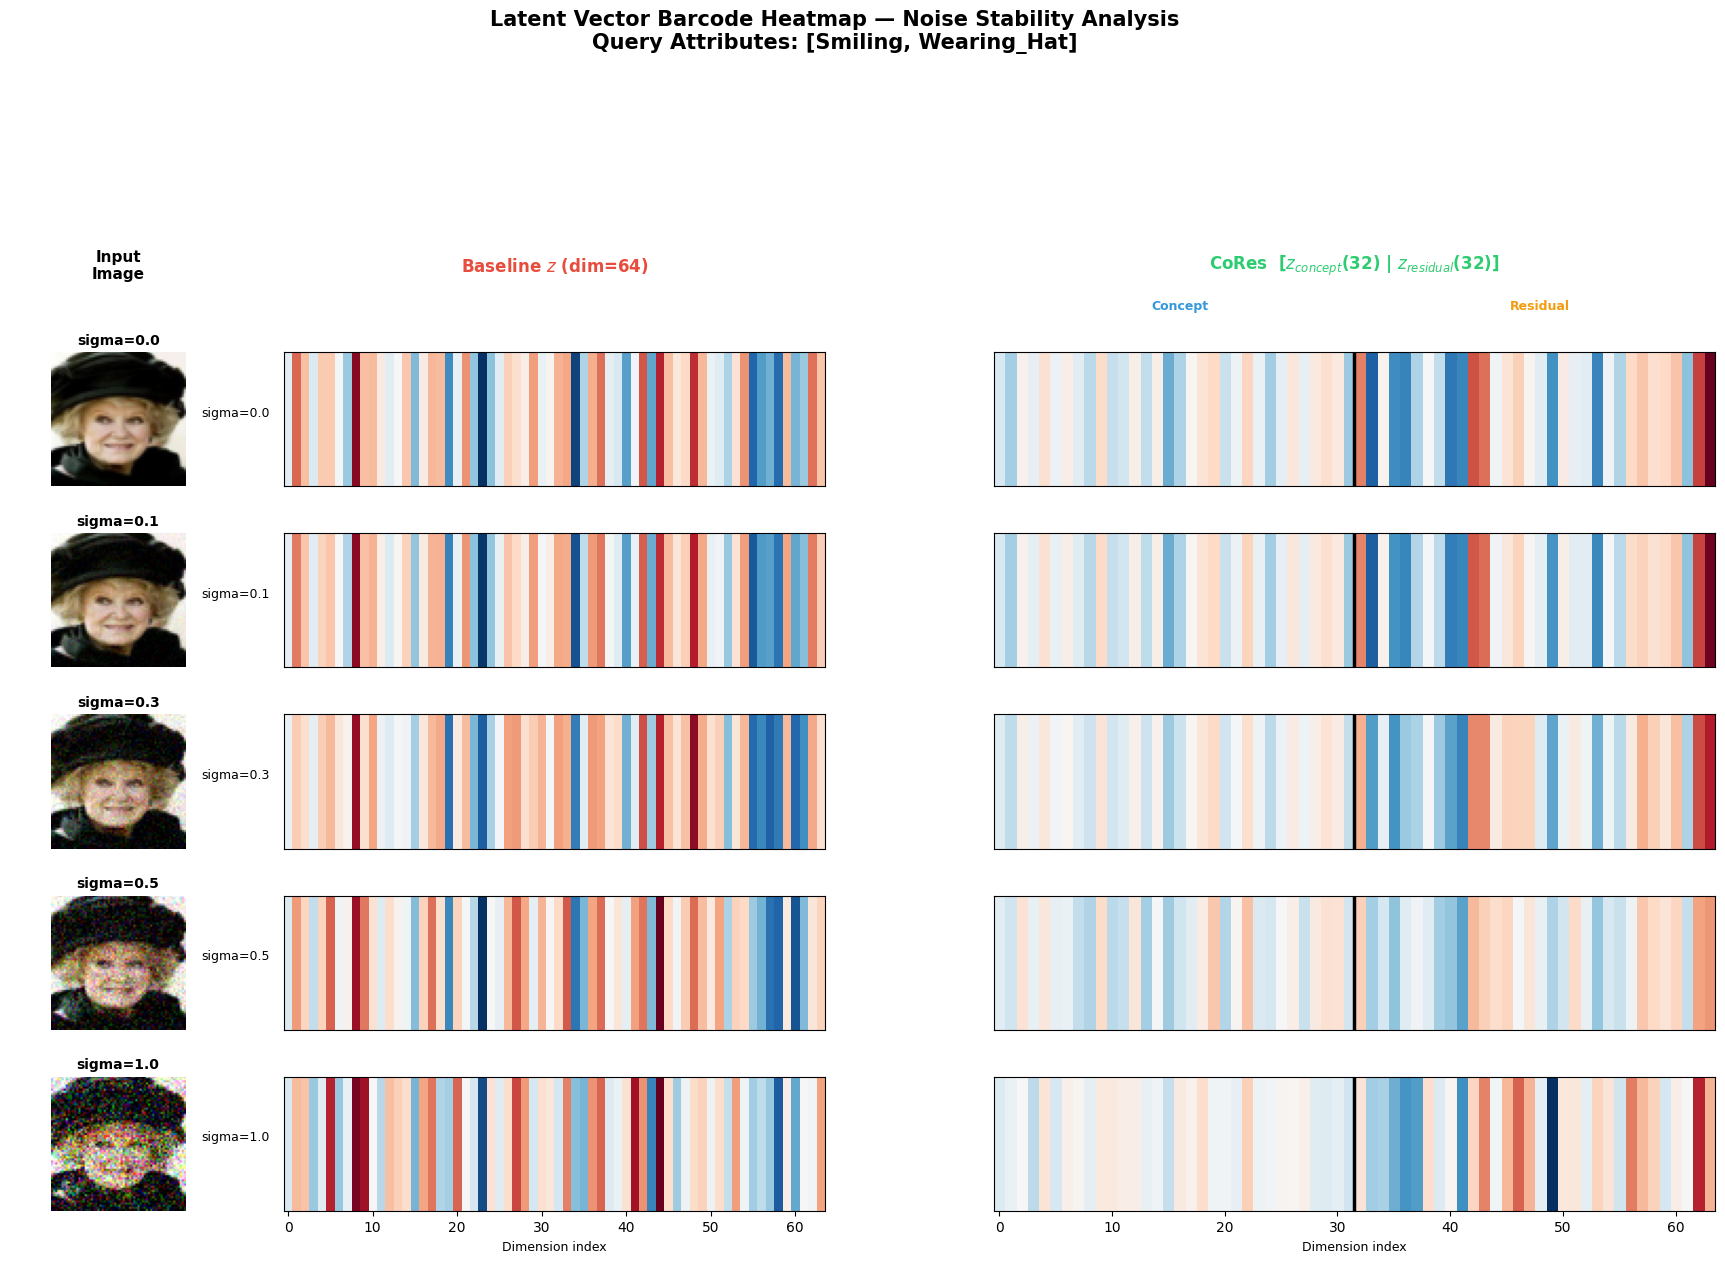


Sample #10: [Male, Eyeglasses, Young]


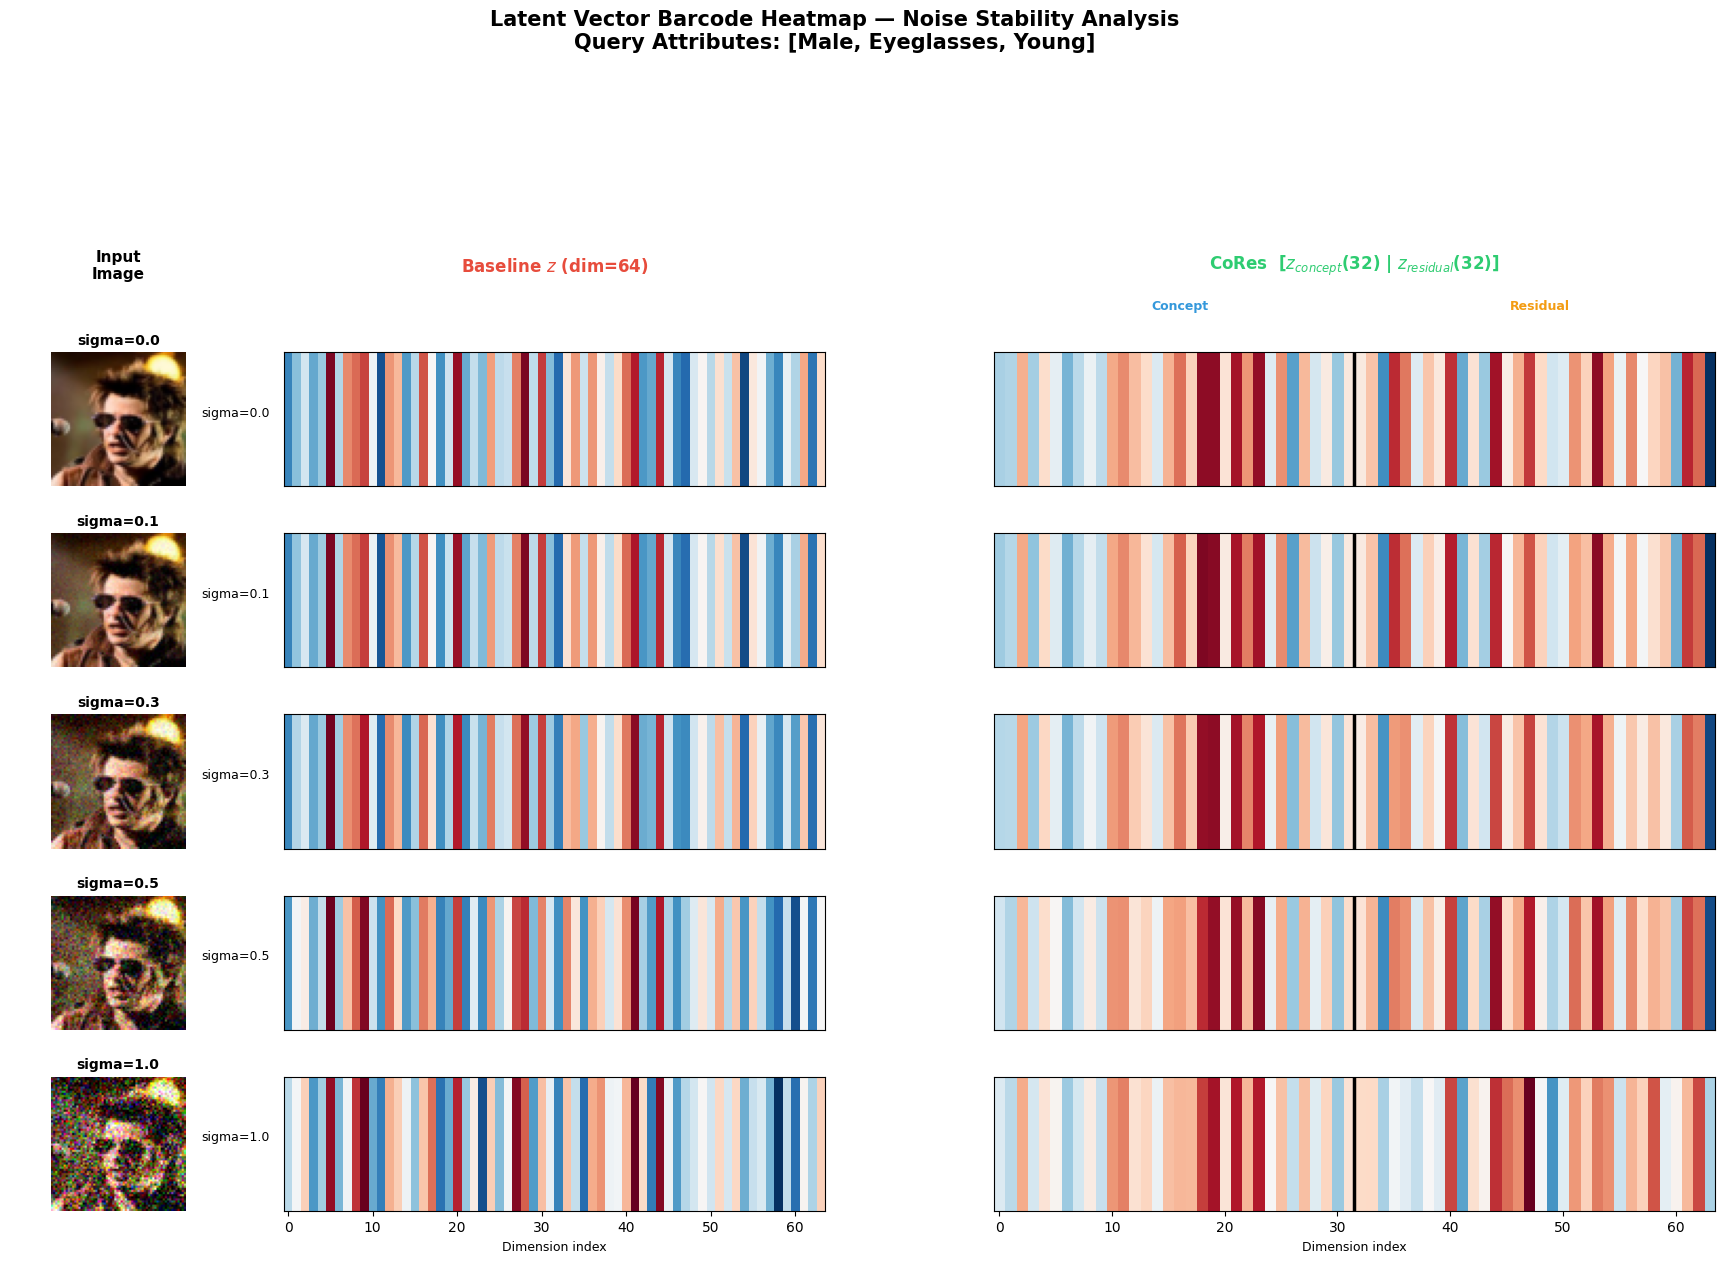


Sample #30: [Smiling, Young, Blond_Hair, Bangs]


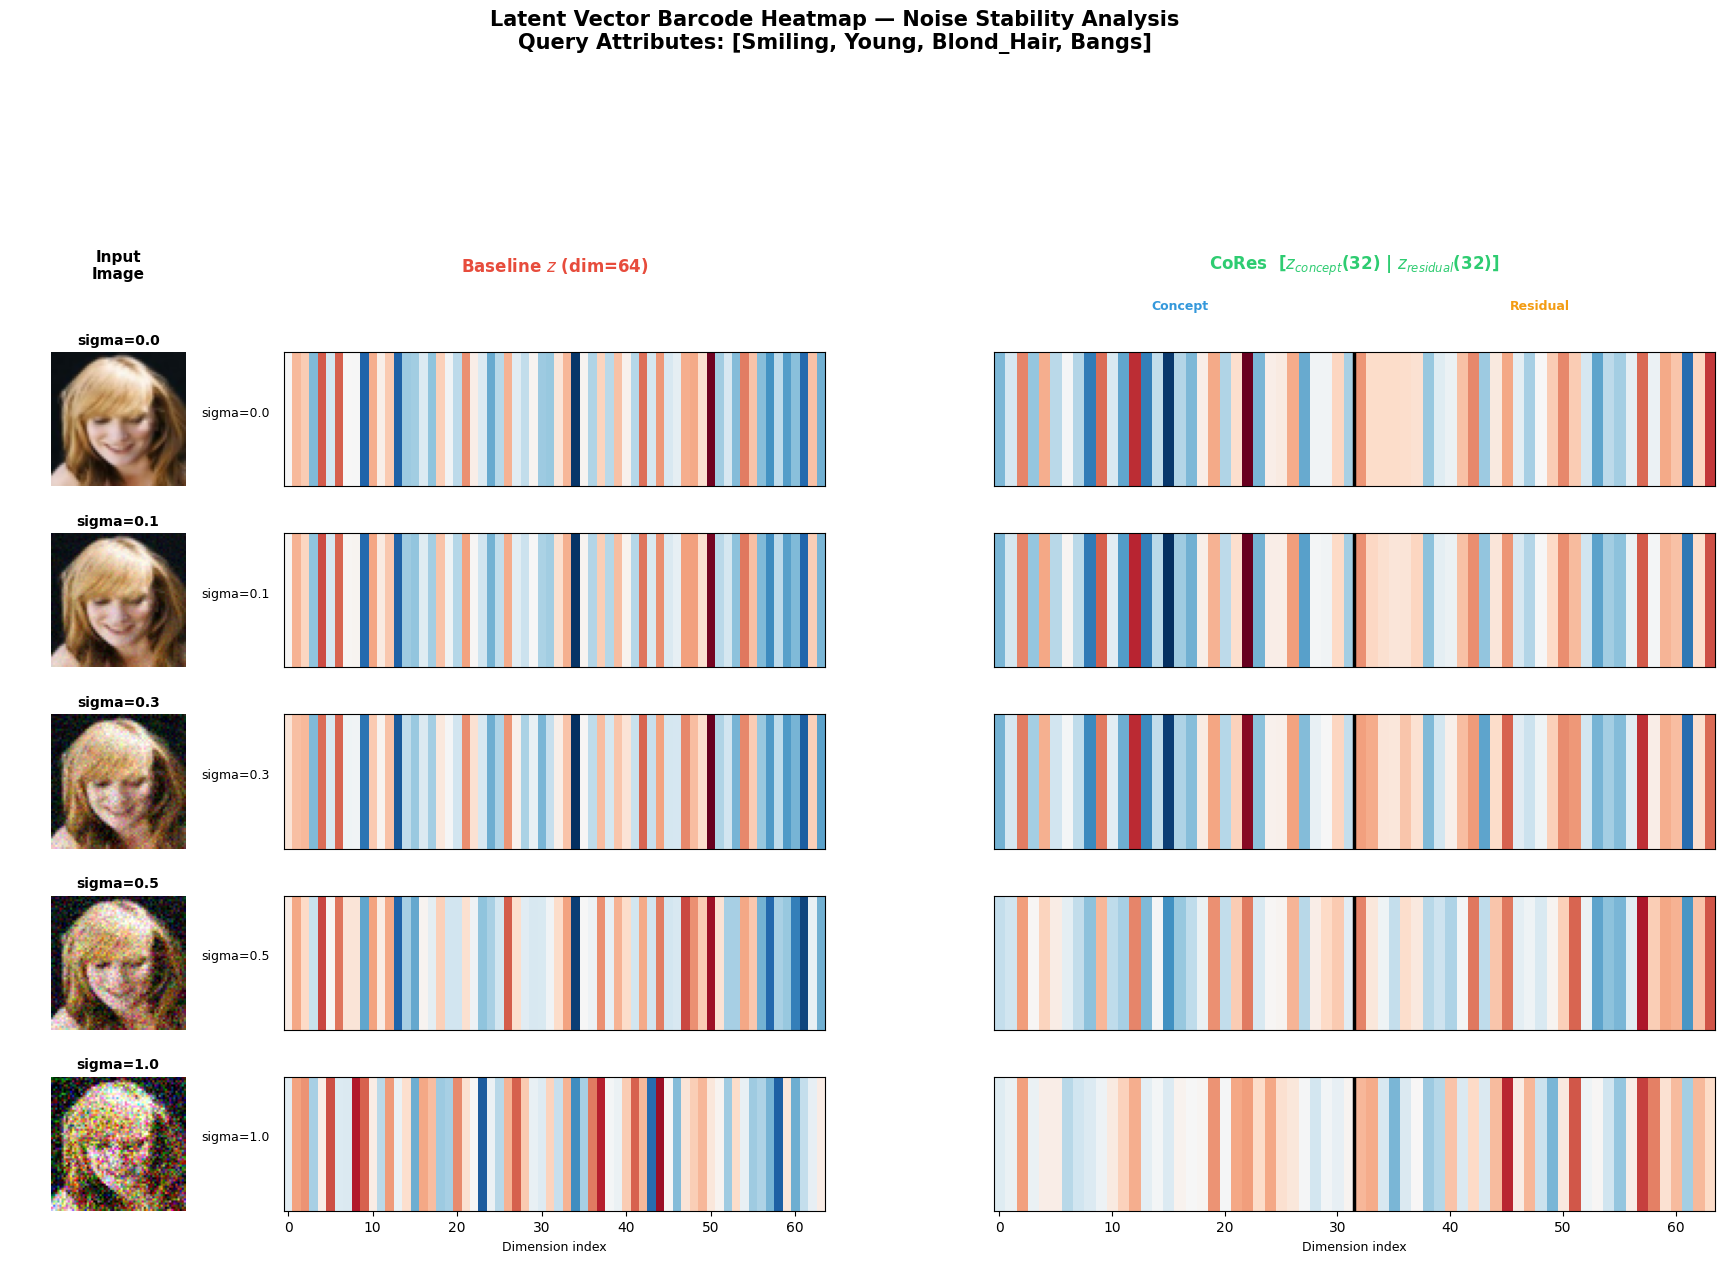


Sample #60: [Young]


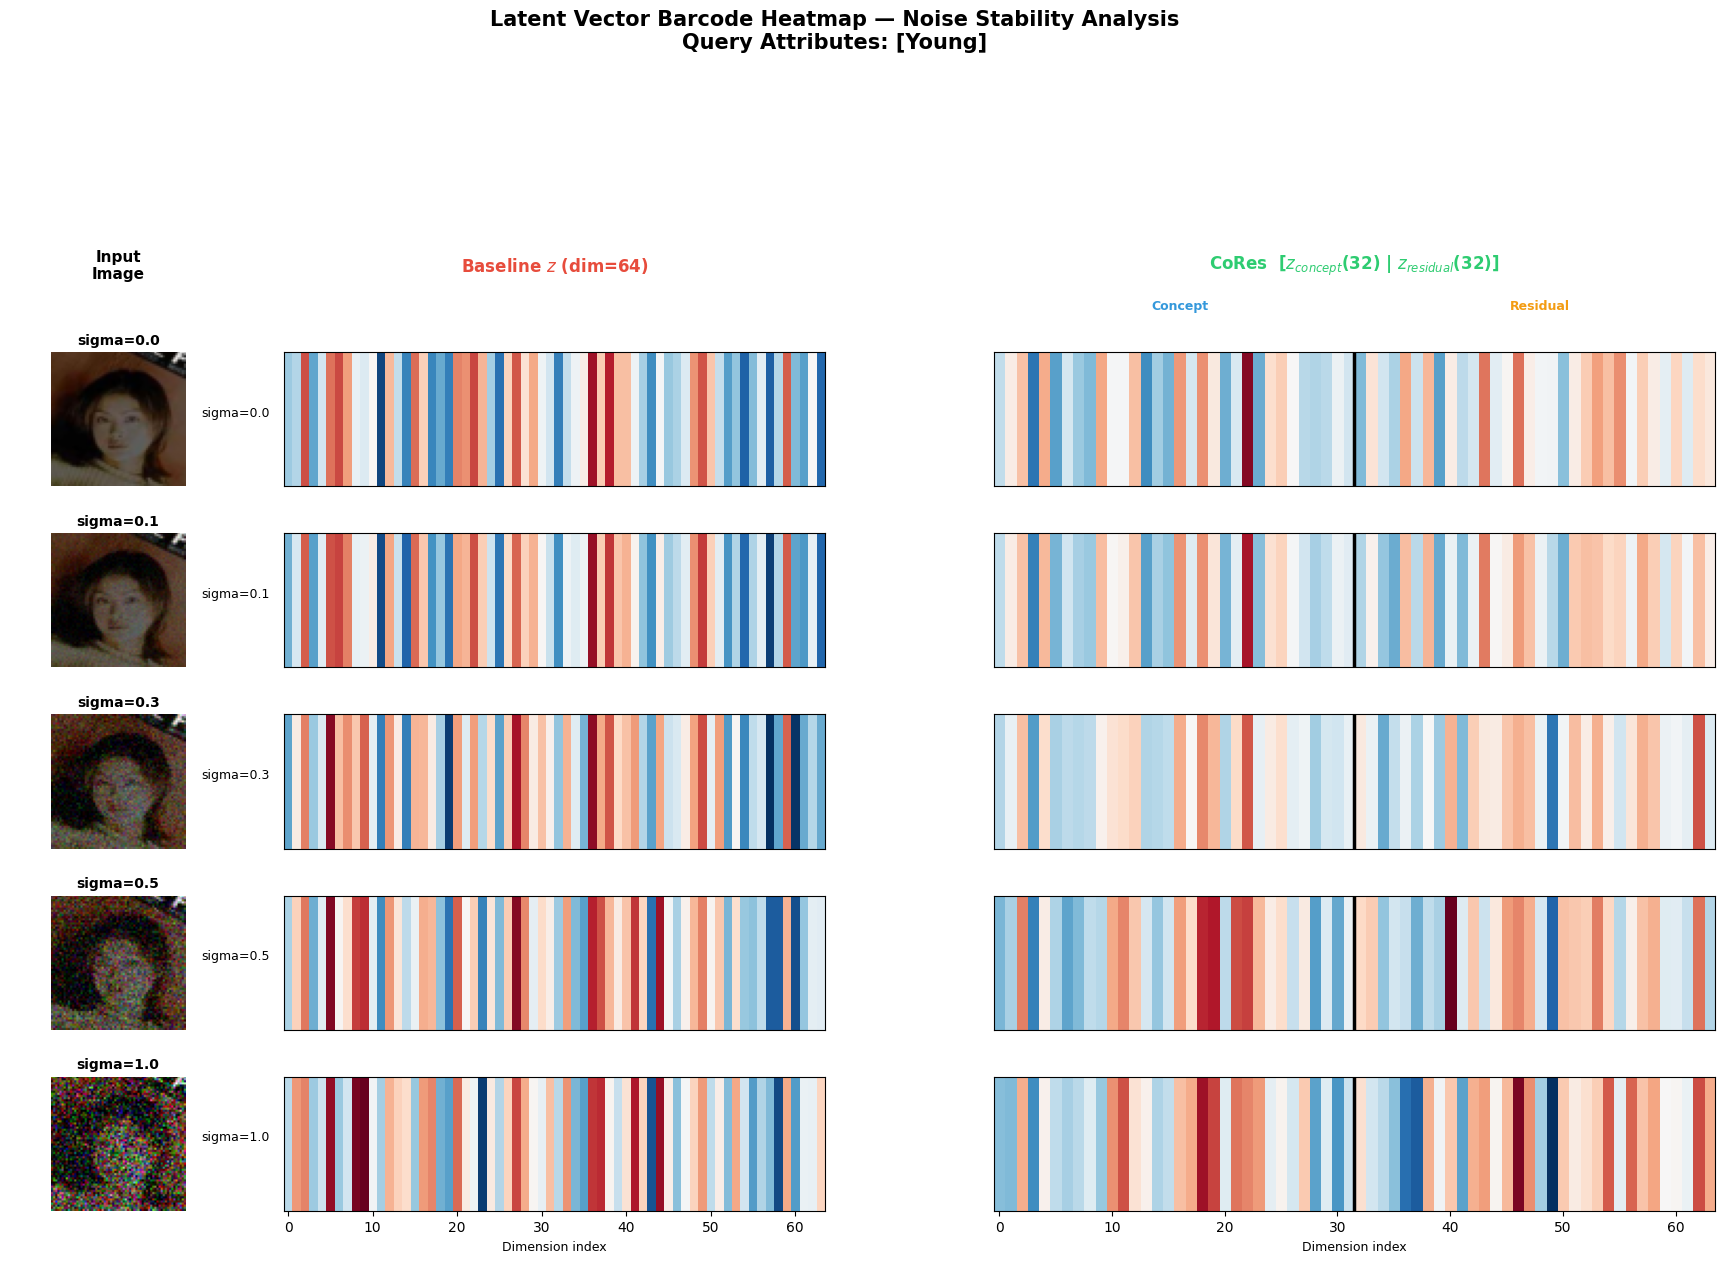


Sample #100: [Young, Black_Hair, Heavy_Makeup]


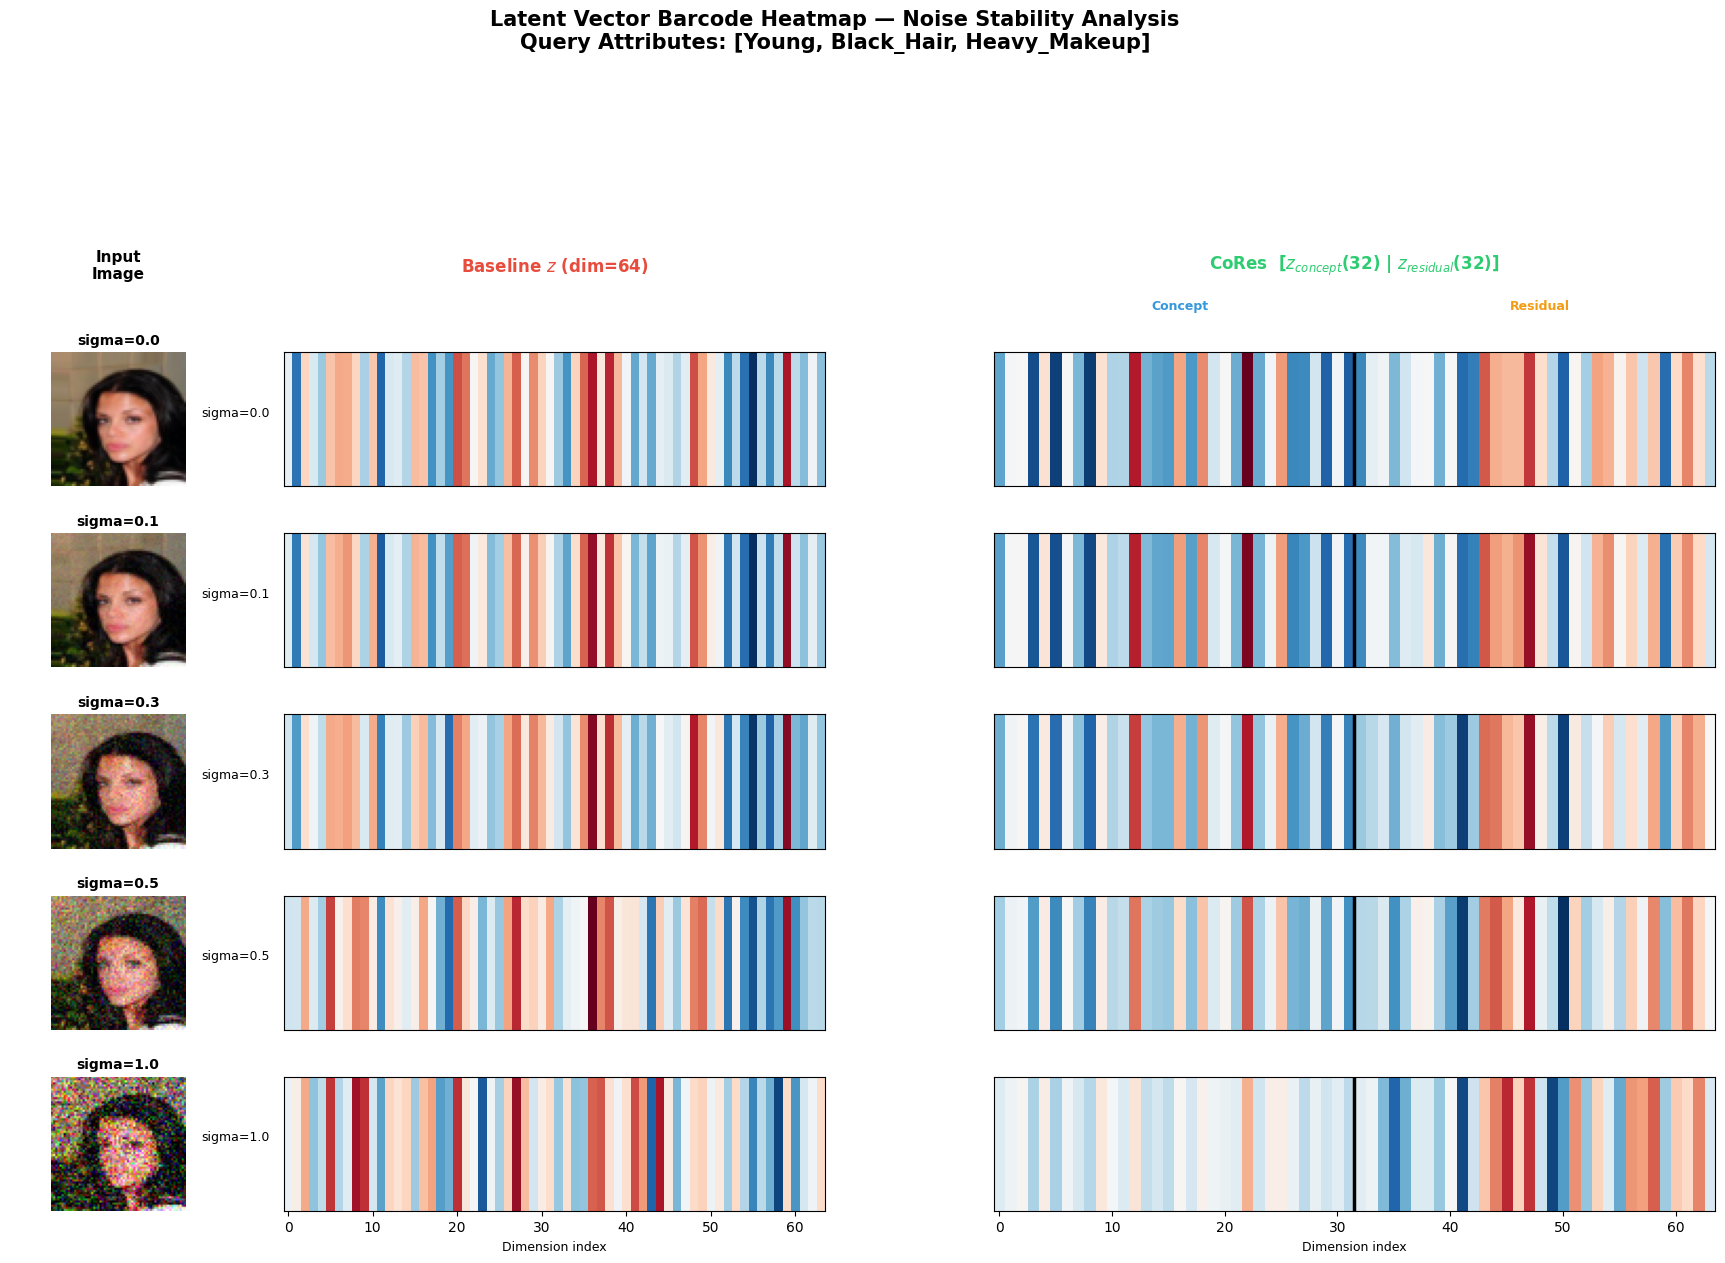

In [7]:
# 여러 샘플에 대해 시각화
NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5, 1.0]
SAMPLE_INDICES = [0, 10, 30, 60, 100]

for idx in SAMPLE_INDICES:
    if idx >= len(test_images):
        continue
    attrs_str = concept_labels_to_str(test_concepts[idx], CONCEPT_ATTRS)
    print(f"\n{'='*60}")
    print(f"Sample #{idx}: [{attrs_str}]")
    print(f"{'='*60}")
    fig = plot_latent_barcode_single(idx, NOISE_LEVELS)
    plt.show()
    plt.close(fig)

## 4. 차원별 변화량 (Delta) 분석

Clean 대비 각 노이즈 수준에서 **각 차원이 얼마나 변했는지** 절대 차이값을 히트맵으로 표시합니다.

$$\Delta z_i = |z_i(x + \epsilon) - z_i(x)|$$

CoRes: Concept 파트의 Delta는 작고, Residual 파트의 Delta는 크게 나타나야 합니다.

In [8]:
def plot_delta_heatmap(query_idx, noise_levels):
    """Clean 대비 차원별 변화량(|Dz|) 히트맵."""
    image = test_images[query_idx]
    concept_label = test_concepts[query_idx]
    attrs_str = concept_labels_to_str(concept_label, CONCEPT_ATTRS)

    noise_nonzero = [s for s in noise_levels if s > 0]
    n_levels = len(noise_nonzero)

    bl_clean = extract_embeddings(baseline_model, image, 0.0)
    cr_clean = extract_embeddings(cores_model, image, 0.0)

    bl_deltas = []
    cr_concept_deltas = []
    cr_residual_deltas = []

    for sigma in noise_nonzero:
        bl_noisy = extract_embeddings(baseline_model, image, sigma)
        cr_noisy = extract_embeddings(cores_model, image, sigma)

        bl_deltas.append(torch.abs(bl_noisy["z"] - bl_clean["z"]).numpy())
        cr_concept_deltas.append(
            torch.abs(cr_noisy["z_concept"] - cr_clean["z_concept"]).numpy()
        )
        cr_residual_deltas.append(
            torch.abs(cr_noisy["z_residual"] - cr_clean["z_residual"]).numpy()
        )

    bl_deltas = np.array(bl_deltas)
    cr_concept_deltas = np.array(cr_concept_deltas)
    cr_residual_deltas = np.array(cr_residual_deltas)

    vmax_all = max(bl_deltas.max(), cr_concept_deltas.max(), cr_residual_deltas.max())

    fig, axes = plt.subplots(1, 3, figsize=(20, 0.8 * n_levels + 2.5),
                             gridspec_kw={"width_ratios": [3, 2, 2], "wspace": 0.3})

    fig.suptitle(
        f"|Dz| Heatmap: Dimension-wise Change from Clean\n"
        f"Sample #{query_idx}: [{attrs_str}]",
        fontsize=14, fontweight="bold", y=1.05,
    )

    sigma_labels = [f"sigma={s}" for s in noise_nonzero]

    im0 = axes[0].imshow(bl_deltas, aspect="auto", cmap="hot_r",
                         vmin=0, vmax=vmax_all, interpolation="nearest")
    axes[0].set_yticks(range(n_levels))
    axes[0].set_yticklabels(sigma_labels, fontsize=9)
    axes[0].set_xlabel("Dimension index", fontsize=10)
    axes[0].set_title(f"Baseline |Dz| (dim={latent_dim})",
                      fontsize=12, fontweight="bold", color="#E74C3C")
    plt.colorbar(im0, ax=axes[0], shrink=0.8, label="|Dz|")

    im1 = axes[1].imshow(cr_concept_deltas, aspect="auto", cmap="hot_r",
                         vmin=0, vmax=vmax_all, interpolation="nearest")
    axes[1].set_yticks(range(n_levels))
    axes[1].set_yticklabels(sigma_labels, fontsize=9)
    axes[1].set_xlabel("Dimension index", fontsize=10)
    axes[1].set_title(f"CoRes |Dz_concept| (dim={concept_dim})",
                      fontsize=12, fontweight="bold", color="#3498DB")
    plt.colorbar(im1, ax=axes[1], shrink=0.8, label="|Dz|")

    im2 = axes[2].imshow(cr_residual_deltas, aspect="auto", cmap="hot_r",
                         vmin=0, vmax=vmax_all, interpolation="nearest")
    axes[2].set_yticks(range(n_levels))
    axes[2].set_yticklabels(sigma_labels, fontsize=9)
    axes[2].set_xlabel("Dimension index", fontsize=10)
    axes[2].set_title(f"CoRes |Dz_residual| (dim={residual_dim})",
                      fontsize=12, fontweight="bold", color="#F39C12")
    plt.colorbar(im2, ax=axes[2], shrink=0.8, label="|Dz|")

    plt.tight_layout()
    return fig

/tmp/ipykernel_1331958/3555993107.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


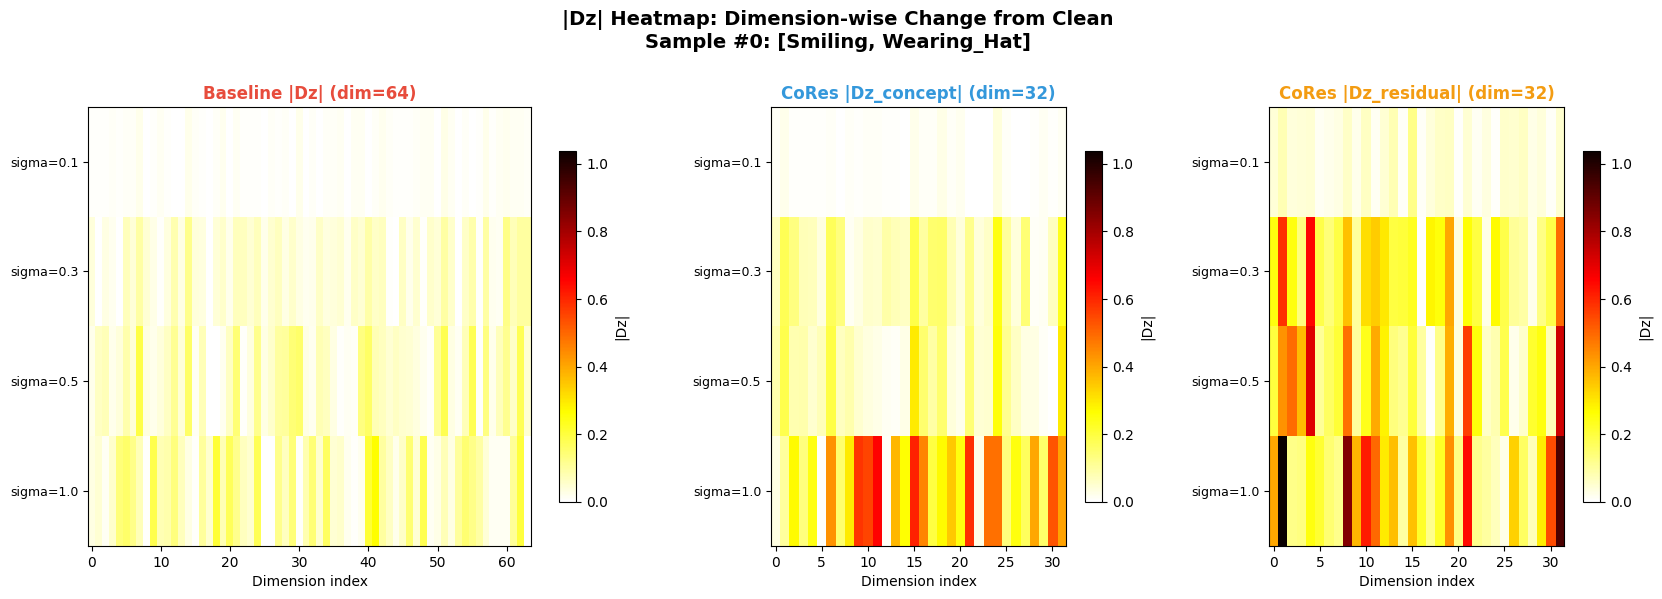

/tmp/ipykernel_1331958/3555993107.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


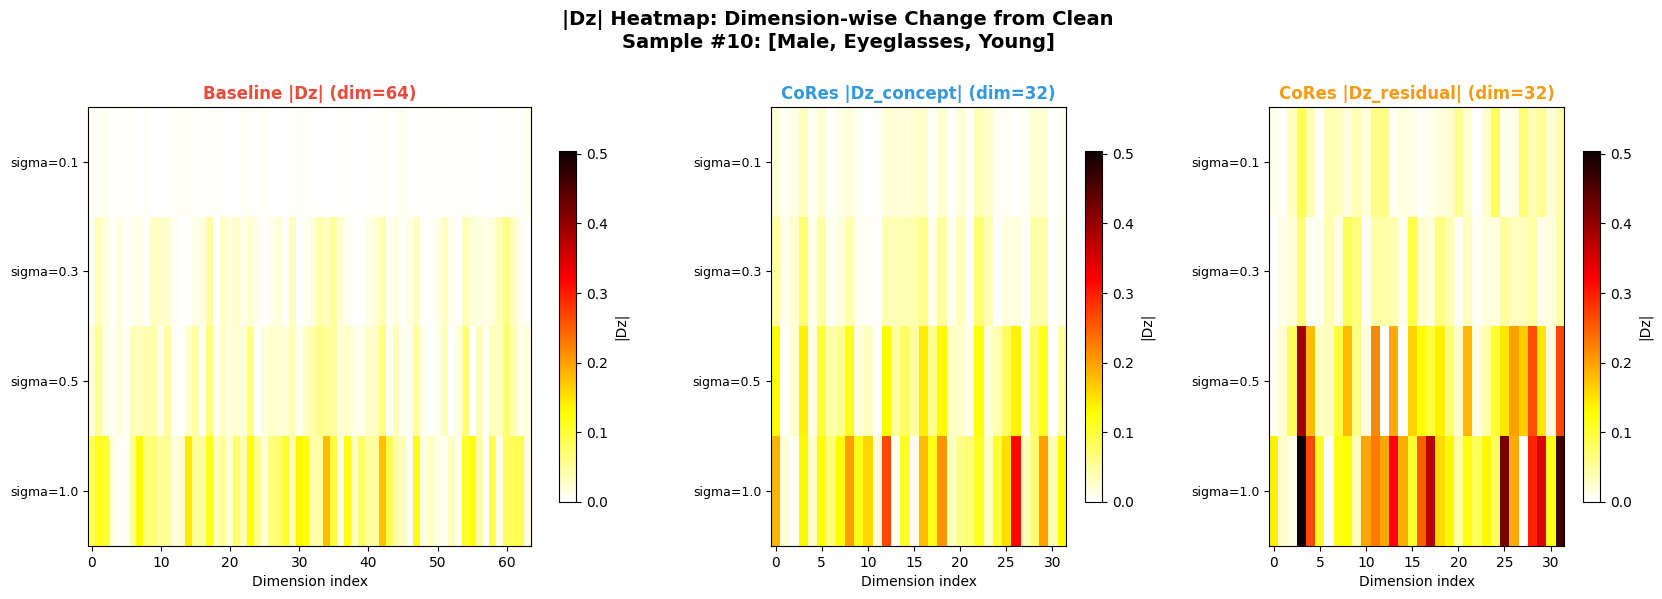

/tmp/ipykernel_1331958/3555993107.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


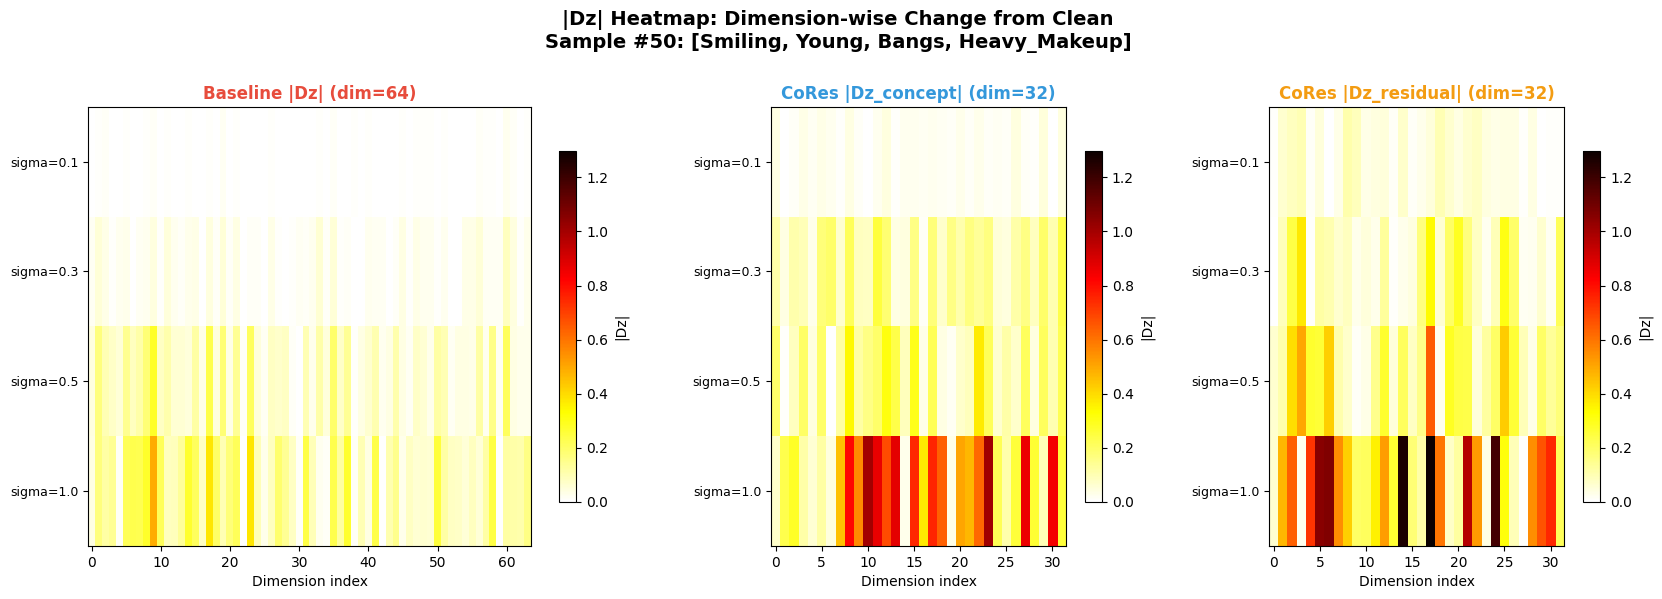

In [9]:
# |Dz| 히트맵 시각화
for idx in [0, 10, 50]:
    if idx >= len(test_images):
        continue
    fig = plot_delta_heatmap(idx, NOISE_LEVELS)
    plt.show()
    plt.close(fig)

## 5. 통계적 집계: 다수 샘플에 대한 평균 변화량

단일 샘플이 아닌 **다수 샘플의 평균**으로 Concept vs Residual 파트의 변화량 차이를 정량적으로 검증합니다.

$$\text{Mean }|\Delta z_{\text{concept}}| \ll \text{Mean }|\Delta z_{\text{residual}}|$$

In [10]:
@torch.no_grad()
def compute_mean_delta_stats(noise_levels, num_samples=100):
    """다수 샘플에 대해 노이즈별 평균 |Dz|를 계산합니다."""
    n = min(num_samples, len(test_images))
    stats = {}

    for sigma in noise_levels:
        if sigma == 0:
            continue

        bl_deltas_all = []
        cr_concept_deltas_all = []
        cr_residual_deltas_all = []

        for i in range(n):
            img = test_images[i]

            bl_clean = extract_embeddings(baseline_model, img, 0.0)
            bl_noisy = extract_embeddings(baseline_model, img, sigma)
            bl_delta = torch.abs(bl_noisy["z"] - bl_clean["z"]).numpy()
            bl_deltas_all.append(bl_delta)

            cr_clean = extract_embeddings(cores_model, img, 0.0)
            cr_noisy = extract_embeddings(cores_model, img, sigma)
            cr_c_delta = torch.abs(cr_noisy["z_concept"] - cr_clean["z_concept"]).numpy()
            cr_r_delta = torch.abs(cr_noisy["z_residual"] - cr_clean["z_residual"]).numpy()
            cr_concept_deltas_all.append(cr_c_delta)
            cr_residual_deltas_all.append(cr_r_delta)

        bl_deltas_all = np.array(bl_deltas_all)
        cr_concept_deltas_all = np.array(cr_concept_deltas_all)
        cr_residual_deltas_all = np.array(cr_residual_deltas_all)

        stats[sigma] = {
            "baseline_mean_delta": bl_deltas_all.mean(),
            "baseline_std_delta": bl_deltas_all.mean(axis=1).std(),
            "concept_mean_delta": cr_concept_deltas_all.mean(),
            "concept_std_delta": cr_concept_deltas_all.mean(axis=1).std(),
            "residual_mean_delta": cr_residual_deltas_all.mean(),
            "residual_std_delta": cr_residual_deltas_all.mean(axis=1).std(),
            "baseline_per_dim": bl_deltas_all.mean(axis=0),
            "concept_per_dim": cr_concept_deltas_all.mean(axis=0),
            "residual_per_dim": cr_residual_deltas_all.mean(axis=0),
        }

    return stats


print("Computing mean |Dz| statistics across samples...")
STAT_NOISE_LEVELS = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
delta_stats = compute_mean_delta_stats(STAT_NOISE_LEVELS, num_samples=100)
print("Done!")

Computing mean |Dz| statistics across samples...
Done!


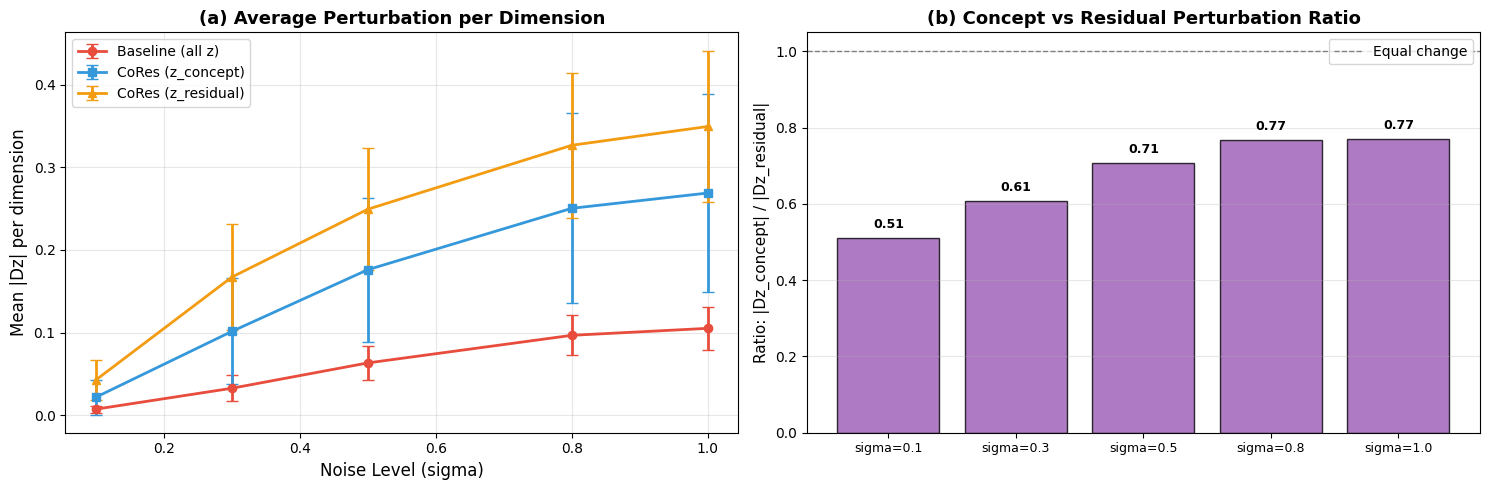

Figure saved


In [11]:
# (a) 평균 |Dz| 그래프: Concept vs Residual vs Baseline
sigmas = sorted(delta_stats.keys())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

bl_means = [delta_stats[s]["baseline_mean_delta"] for s in sigmas]
bl_stds = [delta_stats[s]["baseline_std_delta"] for s in sigmas]
c_means = [delta_stats[s]["concept_mean_delta"] for s in sigmas]
c_stds = [delta_stats[s]["concept_std_delta"] for s in sigmas]
r_means = [delta_stats[s]["residual_mean_delta"] for s in sigmas]
r_stds = [delta_stats[s]["residual_std_delta"] for s in sigmas]

ax1.errorbar(sigmas, bl_means, yerr=bl_stds, marker="o", capsize=4,
             color="#E74C3C", label="Baseline (all z)", linewidth=2)
ax1.errorbar(sigmas, c_means, yerr=c_stds, marker="s", capsize=4,
             color="#3498DB", label="CoRes (z_concept)", linewidth=2)
ax1.errorbar(sigmas, r_means, yerr=r_stds, marker="^", capsize=4,
             color="#F39C12", label="CoRes (z_residual)", linewidth=2)

ax1.set_xlabel("Noise Level (sigma)", fontsize=12)
ax1.set_ylabel("Mean |Dz| per dimension", fontsize=12)
ax1.set_title("(a) Average Perturbation per Dimension", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ratios = [c / r if r > 0 else 0 for c, r in zip(c_means, r_means)]

bars = ax2.bar(range(len(sigmas)), ratios, color="#9B59B6", alpha=0.8, edgecolor="black")
ax2.axhline(y=1.0, color="gray", linestyle="--", linewidth=1, label="Equal change")
ax2.set_xticks(range(len(sigmas)))
ax2.set_xticklabels([f"sigma={s}" for s in sigmas], fontsize=9)
ax2.set_ylabel("Ratio: |Dz_concept| / |Dz_residual|", fontsize=11)
ax2.set_title("(b) Concept vs Residual Perturbation Ratio",
              fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

for bar, ratio in zip(bars, ratios):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{ratio:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "latent_heatmap_mean_delta.pdf"),
            bbox_inches="tight", dpi=300)
plt.show()
print("Figure saved")

## 6. Per-Dimension 변화량 바 차트

특정 노이즈 수준(sigma=0.5)에서, 각 차원의 평균 변화량을 막대 그래프로 표시합니다.
CoRes의 Concept 차원과 Residual 차원이 서로 다른 변화 패턴을 보이는지 확인합니다.

/tmp/ipykernel_1331958/2875283637.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


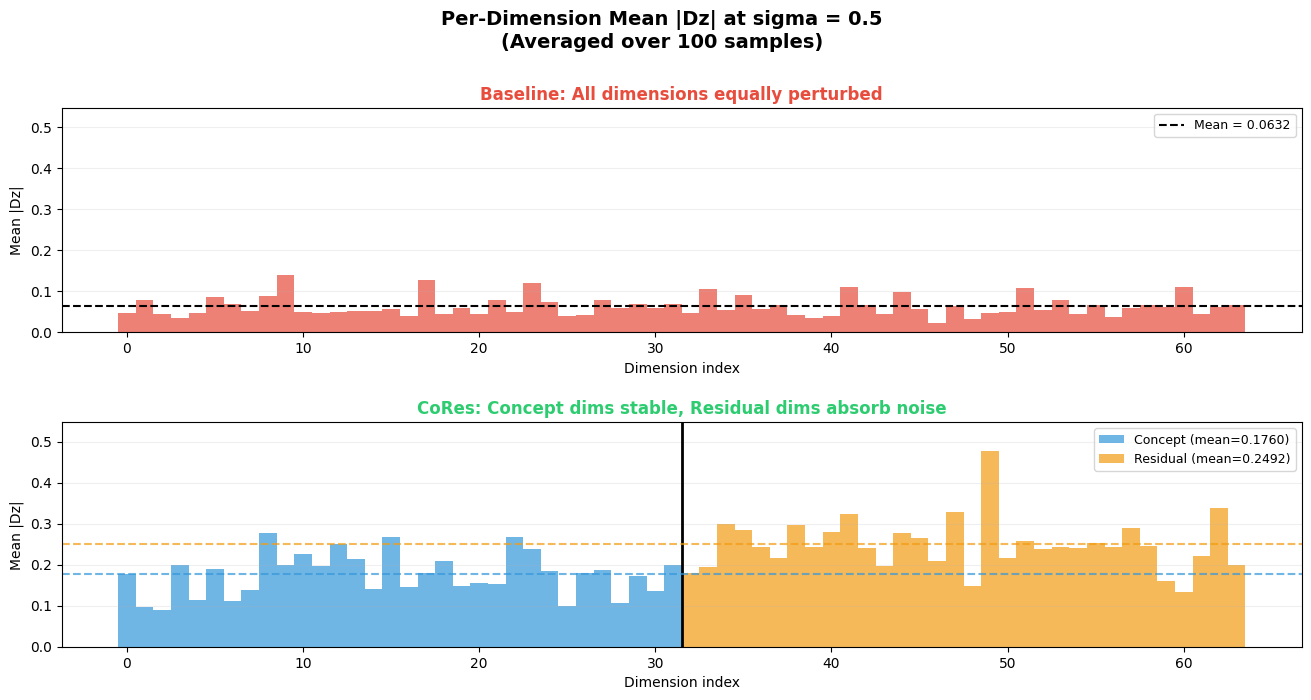

Figure saved


In [12]:
def plot_per_dim_bar(sigma_key=0.5):
    """특정 sigma에서 차원별 평균 |Dz| 막대 그래프."""
    if sigma_key not in delta_stats:
        print(f"sigma={sigma_key} not in stats, available: {list(delta_stats.keys())}")
        return

    s = delta_stats[sigma_key]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7),
                                    gridspec_kw={"hspace": 0.4})

    fig.suptitle(f"Per-Dimension Mean |Dz| at sigma = {sigma_key}\n"
                 f"(Averaged over {min(100, len(test_images))} samples)",
                 fontsize=14, fontweight="bold", y=1.02)

    bl_pd = s["baseline_per_dim"]
    ax1.bar(range(len(bl_pd)), bl_pd, color="#E74C3C", alpha=0.7, width=1.0)
    ax1.set_xlabel("Dimension index", fontsize=10)
    ax1.set_ylabel("Mean |Dz|", fontsize=10)
    ax1.set_title("Baseline: All dimensions equally perturbed",
                  fontsize=12, fontweight="bold", color="#E74C3C")
    ax1.axhline(y=bl_pd.mean(), color="black", linestyle="--",
                label=f"Mean = {bl_pd.mean():.4f}")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.2, axis="y")

    c_pd = s["concept_per_dim"]
    r_pd = s["residual_per_dim"]
    total_dims = len(c_pd) + len(r_pd)

    ax2.bar(range(len(c_pd)), c_pd, color="#3498DB",
            alpha=0.7, width=1.0, label=f"Concept (mean={c_pd.mean():.4f})")
    ax2.bar(range(len(c_pd), total_dims), r_pd, color="#F39C12",
            alpha=0.7, width=1.0, label=f"Residual (mean={r_pd.mean():.4f})")

    ax2.axvline(x=len(c_pd) - 0.5, color="black", linewidth=2, linestyle="-")
    ax2.axhline(y=c_pd.mean(), color="#3498DB", linestyle="--", alpha=0.7)
    ax2.axhline(y=r_pd.mean(), color="#F39C12", linestyle="--", alpha=0.7)

    ax2.set_xlabel("Dimension index", fontsize=10)
    ax2.set_ylabel("Mean |Dz|", fontsize=10)
    ax2.set_title("CoRes: Concept dims stable, Residual dims absorb noise",
                  fontsize=12, fontweight="bold", color="#2ECC71")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.2, axis="y")

    y_max = max(bl_pd.max(), r_pd.max()) * 1.15
    ax1.set_ylim(0, y_max)
    ax2.set_ylim(0, y_max)

    plt.tight_layout()
    return fig


fig = plot_per_dim_bar(sigma_key=0.5)
if fig:
    plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "latent_heatmap_per_dim_bar.pdf"),
                bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print("Figure saved")

## 7. Concept Probability 안정성

CoRes 모델의 **Concept Probability** $p(c_i|x)$가 노이즈 하에서 어떻게 변하는지 확인합니다.
Concept이 정말 안정적인 앵커라면, 이 확률값도 크게 흔들리지 않아야 합니다.

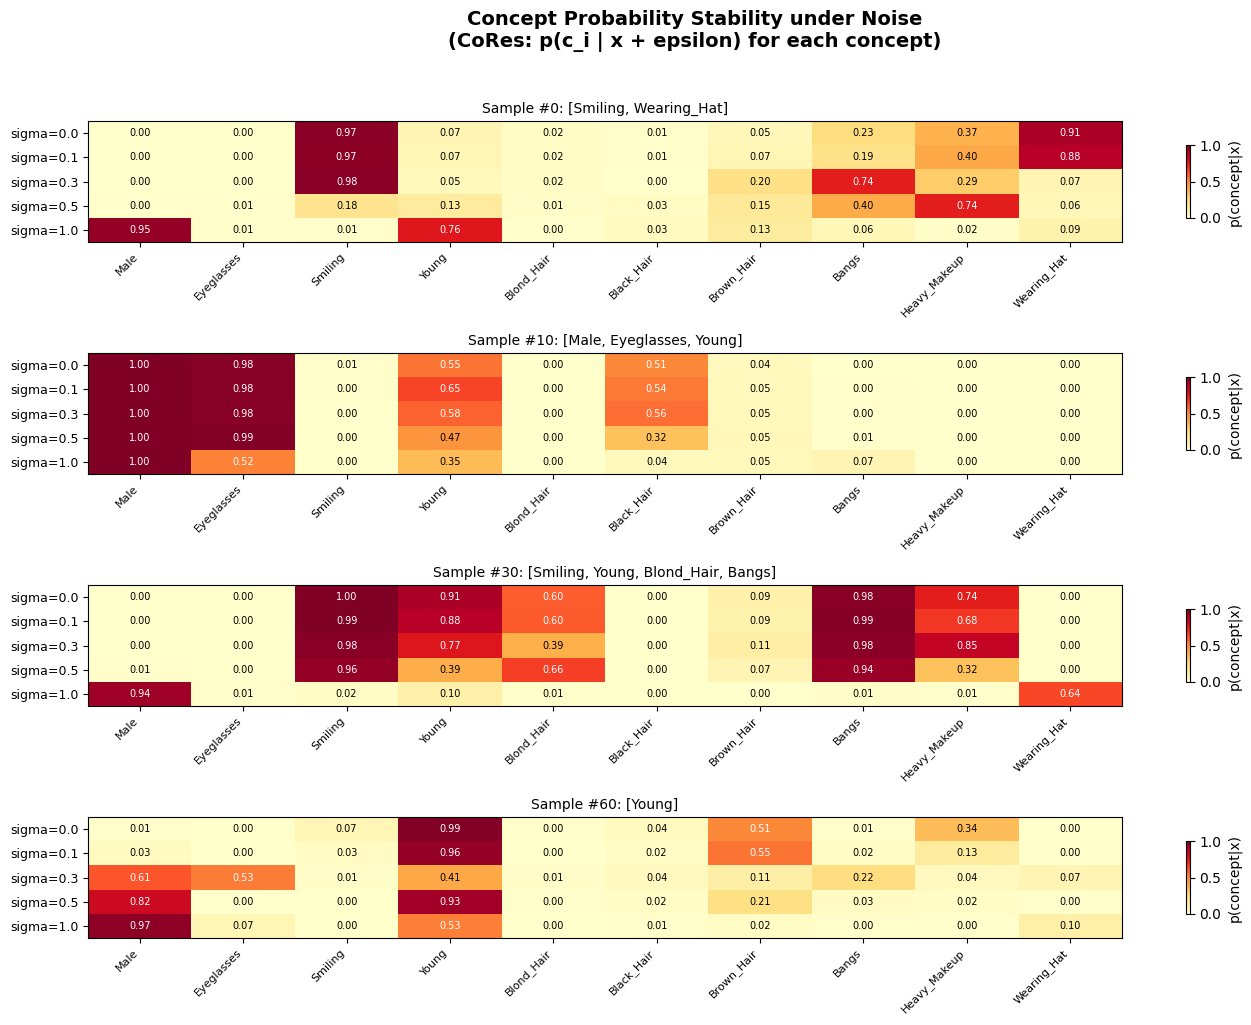

Figure saved


In [13]:
def plot_concept_prob_stability(query_indices, noise_levels):
    """여러 샘플에 대해 노이즈별 Concept Probability 변화를 시각화합니다."""
    n_queries = len(query_indices)
    n_levels = len(noise_levels)

    fig, axes = plt.subplots(
        n_queries, 1, figsize=(14, 2.5 * n_queries),
        squeeze=False,
    )

    fig.suptitle(
        "Concept Probability Stability under Noise\n"
        "(CoRes: p(c_i | x + epsilon) for each concept)",
        fontsize=14, fontweight="bold", y=1.02,
    )

    for row, qi in enumerate(query_indices):
        if qi >= len(test_images):
            continue

        image = test_images[qi]
        attrs_str = concept_labels_to_str(test_concepts[qi], CONCEPT_ATTRS)

        prob_matrix = []
        for sigma in noise_levels:
            cr_emb = extract_embeddings(cores_model, image, sigma)
            prob_matrix.append(cr_emb["concept_probs"].numpy())

        prob_matrix = np.array(prob_matrix)

        ax = axes[row, 0]
        im = ax.imshow(prob_matrix, aspect="auto", cmap="YlOrRd",
                       vmin=0, vmax=1, interpolation="nearest")
        ax.set_yticks(range(n_levels))
        ax.set_yticklabels([f"sigma={s}" for s in noise_levels], fontsize=9)
        ax.set_xticks(range(len(CONCEPT_ATTRS)))
        ax.set_xticklabels(CONCEPT_ATTRS, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"Sample #{qi}: [{attrs_str[:40]}]", fontsize=10)

        for i in range(n_levels):
            for j in range(len(CONCEPT_ATTRS)):
                val = prob_matrix[i, j]
                color = "white" if val > 0.5 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color=color)

        plt.colorbar(im, ax=ax, shrink=0.6, label="p(concept|x)")

    plt.tight_layout()
    return fig


fig = plot_concept_prob_stability(
    query_indices=[0, 10, 30, 60],
    noise_levels=[0.0, 0.1, 0.3, 0.5, 1.0],
)
plt.savefig(os.path.join(PROJECT_ROOT, "outputs", "latent_heatmap_concept_probs.pdf"),
            bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)
print("Figure saved")

## 8. 결과 요약 테이블

In [14]:
# 결과 요약
print("\n" + "=" * 90)
print("SUMMARY: Mean |Dz| per Dimension (Latent Vector Stability)")
print("=" * 90)
print(f"{'Noise (sigma)':>14} | {'Baseline':>14} | {'CoRes Concept':>16} | "
      f"{'CoRes Residual':>16} | {'C/R Ratio':>10}")
print("-" * 90)

for sigma in sorted(delta_stats.keys()):
    s = delta_stats[sigma]
    bl = s["baseline_mean_delta"]
    cc = s["concept_mean_delta"]
    cr = s["residual_mean_delta"]
    ratio = cc / cr if cr > 0 else float("inf")
    print(f"{sigma:>14.2f} | {bl:>14.6f} | {cc:>16.6f} | {cr:>16.6f} | {ratio:>10.3f}")

print("-" * 90)
print("\nInterpretation:")
print("  - C/R Ratio < 1.0: Concept part is more stable than Residual (supports hypothesis)")
print("  - C/R Ratio << 1.0: Concept acts as a strong anchor against noise")
print("  - Baseline: entire vector perturbed uniformly (no structural stability)")
print("  - CoRes Residual absorbs noise like a lightning rod, protecting Concept")


SUMMARY: Mean |Dz| per Dimension (Latent Vector Stability)
 Noise (sigma) |       Baseline |    CoRes Concept |   CoRes Residual |  C/R Ratio
------------------------------------------------------------------------------------------
          0.10 |       0.007215 |         0.021683 |         0.042555 |      0.510
          0.30 |       0.032523 |         0.101348 |         0.167086 |      0.607
          0.50 |       0.063191 |         0.176043 |         0.249223 |      0.706
          0.80 |       0.096598 |         0.250350 |         0.326648 |      0.766
          1.00 |       0.105052 |         0.268838 |         0.349389 |      0.769
------------------------------------------------------------------------------------------

Interpretation:
  - C/R Ratio < 1.0: Concept part is more stable than Residual (supports hypothesis)
  - C/R Ratio << 1.0: Concept acts as a strong anchor against noise
  - Baseline: entire vector perturbed uniformly (no structural stability)
  - CoRes Residu